In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# sktime — time-series forecasting toolkit
from sktime.forecasting.ets import AutoETS
from sktime.forecasting.base import ForecastingHorizon
from sktime.performance_metrics.forecasting import mean_absolute_percentage_error


In [2]:
# Load the data
# Settings 
STATION_ID = 10       # Dame Street — has dense data across the whole month
TEST_HOURS = 168      # hold out the last 7 days (7 × 24 = 168 hours) for evaluation

# Load raw data 
df_raw = pd.read_csv('final_merged_data.csv', low_memory=False)

# Build hourly series for Station 10 
ts = (
    df_raw[df_raw["station_id"] == STATION_ID]      # keep only our chosen station
    .assign(dt=lambda d: pd.to_datetime(d["last_reported"]).dt.floor("h"))  # round down to hour
    .groupby("dt")["num_bikes_available"]            # group all readings in the same hour
    .mean()                                          # take the average bike count
    .sort_index()                                    # make sure time goes forward
)


print(f"Total hourly observations : {len(ts)}")
print(f"Date range               : {ts.index.min()}  →  {ts.index.max()}")
print(f"Min / Mean / Max bikes   : {ts.min():.1f} / {ts.mean():.1f} / {ts.max():.1f}")
ts.head(8)


Total hourly observations : 679
Date range               : 2024-12-01 00:00:00  →  2024-12-31 22:00:00
Min / Mean / Max bikes   : 2.0 / 12.9 / 16.0


dt
2024-12-01 00:00:00    12.800000
2024-12-01 01:00:00    12.000000
2024-12-01 02:00:00    12.000000
2024-12-01 03:00:00    12.000000
2024-12-01 04:00:00    12.000000
2024-12-01 05:00:00    12.000000
2024-12-01 06:00:00    11.333333
2024-12-01 07:00:00    11.833333
Name: num_bikes_available, dtype: float64

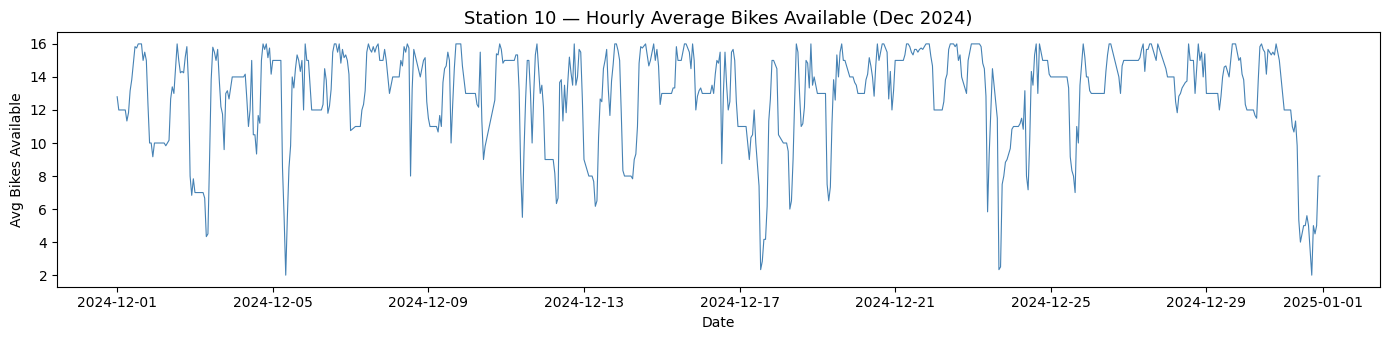

We can clearly see the daily pattern:  fewer bikes during commute hours (8-9am, 5-6pm).


In [3]:
plt.figure(figsize=(14, 3.5))
plt.plot(ts.index, ts.values, linewidth=0.8, color='steelblue')
plt.title(f"Station {STATION_ID} — Hourly Average Bikes Available (Dec 2024)", fontsize=13)
plt.xlabel("Date"); plt.ylabel("Avg Bikes Available")
plt.tight_layout(); plt.show()

print("We can clearly see the daily pattern:  fewer bikes during commute hours (8-9am, 5-6pm).")

## Train / Test Split

For time series we **never shuffle** — the past trains the model, the future is the test.  
We hold out the **last 168 hours (7 days)** and train on everything before that.

In [4]:
# sktime wants a PeriodIndex, not a DatetimeIndex 
ts_period = ts.copy()
ts_period.index = pd.PeriodIndex(ts_period.index, freq="h")   # 'h' = hourly

# Split: all rows except the last TEST_HOURS go to training
y_train = ts_period.iloc[:-TEST_HOURS]
y_test  = ts_period.iloc[-TEST_HOURS:]

print(f"Training set : {len(y_train)} hours  ({y_train.index[0]}  →  {y_train.index[-1]})")
print(f"Test set     : {len(y_test)} hours   ({y_test.index[0]}  →  {y_test.index[-1]})")


Training set : 511 hours  (2024-12-01 00:00  →  2024-12-23 23:00)
Test set     : 168 hours   (2024-12-24 00:00  →  2024-12-31 22:00)


In [12]:
!pip install statsmodels 

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.3/9.6 MB 12.3 MB/s eta 0:00:01
   -------------------- ------------------- 5.0/9.6 MB 15.9 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.6 MB 16.5 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 13.4 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   --------

## Fit AutoETS

`AutoETS` automatically searches for the best combination of:
- **Error** type (additive / multiplicative)  
- **Trend** component (none / additive / multiplicative)  
- **Seasonality** component (none / additive / multiplicative)  

We tell it `sp=24` because our data has a **24-hour seasonal cycle** (one full day).  
`auto=True` means it will try multiple combinations and pick the best one.  
`n_jobs=-1` uses all available CPU cores to speed things up.

In [5]:
# Fit the AutoETS forecaster on the training set
forecaster = AutoETS(auto=True, sp=24, n_jobs=-1)
forecaster.fit(y_train)

print("AutoETS fitted")
print(f"Best model selected: {forecaster.summary()}")   # shows which ETS variant won

AutoETS fitted
Best model selected:                                   ETS Results                                  
Dep. Variable:     num_bikes_available   No. Observations:                  511
Model:                        ETS(ANN)   Log Likelihood               -1011.339
Date:                 Tue, 07 Apr 2026   AIC                           2028.678
Time:                         18:26:22   BIC                           2041.387
Sample:                     12-01-2024   HQIC                          2033.660
                          - 12-23-2024   Scale                            3.066
Covariance Type:                approx                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
smoothing_level     0.9999      0.055     18.061      0.000       0.891       1.108
initial_level      12.8006      1.752      7.308      0.000       9.368 

## Generate Forecasts

We create a `ForecastingHorizon` using the test-set index so the forecaster knows  
**exactly which time steps** to predict.  Setting `is_relative=False` means we're  
giving absolute timestamps, not "predict 1 step ahead, 2 steps ahead…"

In [6]:
# Build the forecasting horizon from the test-set timestamps
fh = ForecastingHorizon(y_test.index, is_relative=False)

# Predict
y_pred = forecaster.predict(fh)

print(f"Forecast generated for {len(y_pred)} hours ✓")
y_pred.head()


Forecast generated for 168 hours ✓


dt
2024-12-24 00:00    9.666633
2024-12-24 01:00    9.666633
2024-12-24 02:00    9.666633
2024-12-24 03:00    9.666633
2024-12-24 04:00    9.666633
Freq: h, Name: num_bikes_available, dtype: float64

## Evaluate — MAPE

**MAPE** (Mean Absolute Percentage Error) tells how far off our predictions are  
*as a percentage of the true values*.  A MAPE of 15% means we're wrong by 15% on average.

Lower is better.  For bike-sharing, anything below ~20% is considered decent  
given how noisy real-world demand can be.

In [7]:
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"MAPE on test set (last 7 days): {mape:.2%}")

MAPE on test set (last 7 days): 34.88%


## Plot — Actual vs Forecast

The plot below shows the **last 3 weeks of training + the full test week**.  
Blue = training history, green = actual test values, red = what AutoETS predicted.

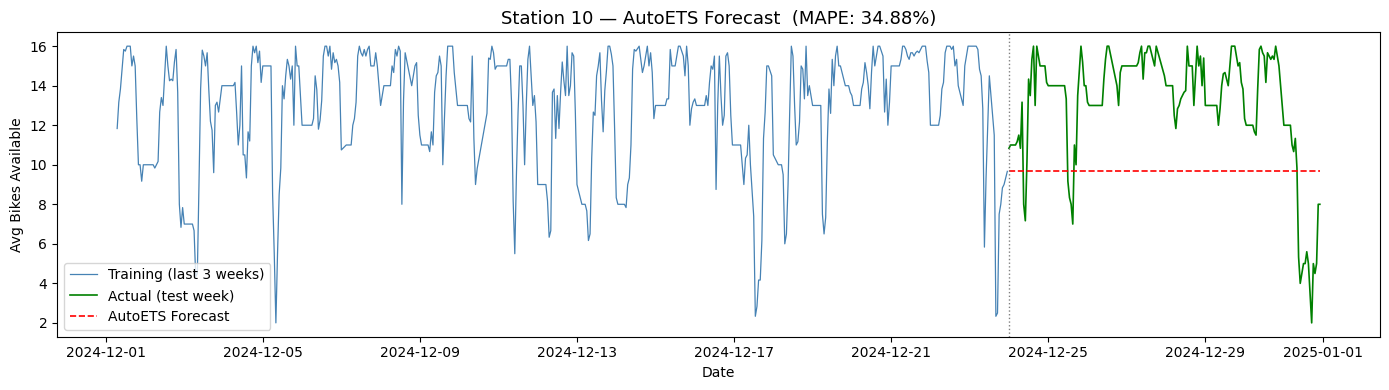

In [8]:
# Convert PeriodIndex back to DatetimeIndex for nicer axis labels
y_train_dt = y_train.copy(); y_train_dt.index = y_train_dt.index.to_timestamp()
y_test_dt  = y_test.copy();  y_test_dt.index  = y_test_dt.index.to_timestamp()
y_pred_dt  = y_pred.copy();  y_pred_dt.index  = y_pred_dt.index.to_timestamp()

# Only plot the last 3 weeks of training so the chart isn't too cramped
plot_train = y_train_dt.iloc[-3*24*7:]

plt.figure(figsize=(14, 4))
plt.plot(plot_train.index, plot_train.values,    color='steelblue', label='Training (last 3 weeks)', linewidth=0.9)
plt.plot(y_test_dt.index,  y_test_dt.values,     color='green',     label='Actual (test week)',     linewidth=1.2)
plt.plot(y_pred_dt.index,  y_pred_dt.values,     color='red',       label='AutoETS Forecast',       linewidth=1.2, linestyle='--')

plt.axvline(y_test_dt.index[0], color='grey', linestyle=':', linewidth=1)
plt.title(f"Station {STATION_ID} — AutoETS Forecast  (MAPE: {mape:.2%})", fontsize=13)
plt.xlabel("Date"); plt.ylabel("Avg Bikes Available")
plt.legend(); plt.tight_layout(); plt.show()


## Key Findings 

**Why sktime instead of sklearn here?**  
- sklearn models (like RandomForest) treat each row independently.  
  They are great when we have rich feature tables.  
- sktime models *know* about time ordering and can model trends and seasonality  
  from the series itself — useful when we only have the historical counts.

**Comparison with the main notebook:**  
The RandomForest (MAE ≈ 1.43, R² ≈ 0.93) is much stronger *across all stations* because  
it uses weather, hour, capacity and station identity as features.  
AutoETS is simpler but trains on a **single station** with only the count history,  
making it useful when rich features are unavailable or for quick prototyping.